# Cell 1: Imports

In [2]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_curve,auc
from sklearn.linear_model import LogisticRegression as SklearnLR
np.random.seed(42)

# Cell 2:

In [3]:
# Logistic Regression equations
# z=X@w+b
# yhat=sigmoid(z)
# BCE loss


# Cell 3: Sigmoid

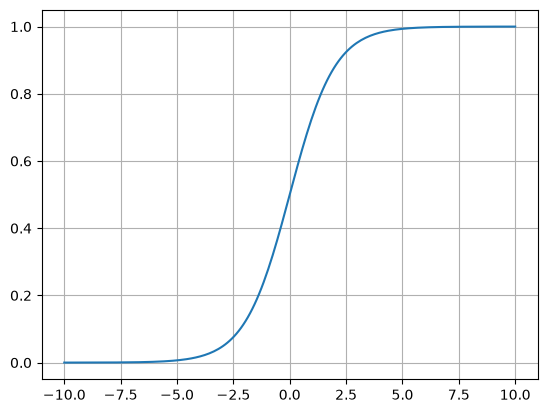

In [4]:
def sigmoid(z):
    z=np.clip(z,-500,500)
    return 1/(1+np.exp(-z))

z=np.linspace(-10,10,200)
plt.plot(z,sigmoid(z));plt.grid();plt.show()

# Cell 4: Class

In [5]:
class LogisticRegressionScratch:
    def __init__(self,learning_rate=0.1,n_iterations=2000):
        self.lr=learning_rate; self.n_iterations=n_iterations
    @staticmethod
    def sigmoid(z):
        return 1/(1+np.exp(-np.clip(z,-500,500)))
    def _forward(self,X):
        z=X@self.weights+self.bias
        return z,self.sigmoid(z)
    def _loss(self,y,p):
        p=np.clip(p,1e-15,1-1e-15)
        return -np.mean(y*np.log(p)+(1-y)*np.log(1-p))
    def fit(self,X,y):
        m,n=X.shape; self.weights=np.zeros(n); self.bias=0.; self.loss_history=[]
        for _ in range(self.n_iterations):
            z,p=self._forward(X); self.loss_history.append(self._loss(y,p));
            dw=X.T@(p-y)/m; db=np.mean(p-y); self.weights-=self.lr*dw; self.bias-=self.lr*db
        return self
    def predict_proba(self,X):
        return self._forward(X)[1]
    def predict(self,X,t=0.5):
        return (self.predict_proba(X)>=t).astype(int)
    def score(self,X,y):
        return np.mean(self.predict(X)==y)

# Cell 5: Data

In [6]:
X,y=make_classification(n_samples=500,n_features=2,n_redundant=0,n_informative=2,random_state=42)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Cell 6: Train

In [7]:
model=LogisticRegressionScratch().fit(X_train,y_train)
print(model.score(X_test,y_test))

0.88


# Cell 7: Loss

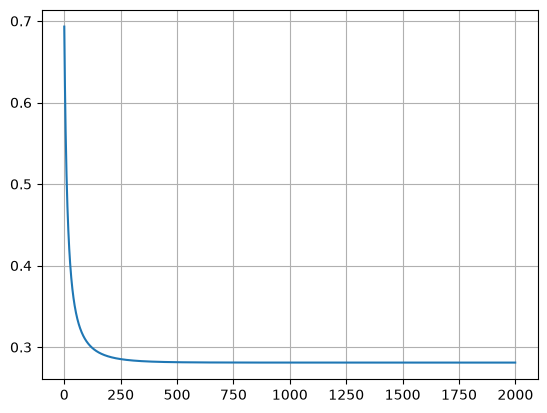

In [8]:
plt.plot(model.loss_history);plt.grid();plt.show()

# Cell 8: Boundary

In [ ]:
# Decision boundary visualization placeholder

# Cell 9: Evaluation

In [9]:
pred=model.predict(X_test)
print(classification_report(y_test,pred))
print(confusion_matrix(y_test,pred))

              precision    recall  f1-score   support

           0       0.91      0.84      0.88        50
           1       0.85      0.92      0.88        50

    accuracy                           0.88       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.88      0.88      0.88       100

[[42  8]
 [ 4 46]]


# Cell 10: Compare

In [10]:
sk=SklearnLR(max_iter=2000).fit(X_train,y_train)
print('Scratch',model.score(X_test,y_test))
print('Sklearn',sk.score(X_test,y_test))

Scratch 0.88
Sklearn 0.88
